### ASDRP DRONE


In [1]:
import os
import time
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from PIL import Image
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)

import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)



Device: cpu


In [2]:
class HazardDetectionDataset(Dataset):
    """
    Per item:
      image: FloatTensor (3,H,W)
      target: dict with boxes (N,4), labels (N,)
      hazard: int (0/1)
    """

    def __init__(self, records):
        self.records = records
        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        image = Image.open(r["image_path"]).convert("RGB")
        image = self.to_tensor(image)

        boxes = r["boxes"].clone().float()
        labels = r["labels"].clone().long()
        hazard = int(r["hazard_label"])

        target = {"boxes": boxes, "labels": labels}
        return image, target, hazard


def collate_fn(batch):
    images, targets, hazards = zip(*batch)
    return list(images), list(targets), torch.tensor(hazards, dtype=torch.long)


def _map_category_to_label(cat_name):
    n = cat_name.strip().lower()
    if "power line" in n or "powerline" in n:
        return 1
    if "vegetation" in n:
        return 2
    return None


def _build_records_from_split(coco_json_path, images_dir):
    import json

    with open(coco_json_path, "r") as f:
        coco = json.load(f)

    images = {img["id"]: img for img in coco["images"]}
    anns_by_img = {}
    for ann in coco["annotations"]:
        anns_by_img.setdefault(ann["image_id"], []).append(ann)

    cat_id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
    cat_id_to_label = {}
    for cid, name in cat_id_to_name.items():
        mapped = _map_category_to_label(name)
        if mapped is not None:
            cat_id_to_label[cid] = mapped

    records = []
    skipped_missing = 0

    for img_id, info in images.items():
        img_path = os.path.join(images_dir, info["file_name"])
        if not os.path.exists(img_path):
            skipped_missing += 1
            continue

        boxes = []
        labels = []
        has_powerline = False
        has_vegetation = False
        has_combined = False

        for ann in anns_by_img.get(img_id, []):
            cid = ann.get("category_id")
            cname = cat_id_to_name.get(cid, "").strip().lower()

            if "vegetation-on-powerlines" in cname:
                has_combined = True
            if "power line" in cname or "powerline" in cname:
                has_powerline = True
            if "vegetation" in cname:
                has_vegetation = True

            mapped = cat_id_to_label.get(cid)
            if mapped is None:
                continue

            x, y, w, h = ann["bbox"]
            if w <= 1 or h <= 1:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(mapped)

        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.long)
        else:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.long)

        hazard = int(has_combined or (has_powerline and has_vegetation))

        records.append({
            "image_path": img_path,
            "boxes": boxes_t,
            "labels": labels_t,
            "hazard_label": hazard,
        })

    return records, skipped_missing


def load_coco_records(coco_root, trainval_splits=("train", "valid"), test_split="test"):
    trainval_records = []
    test_records = []

    for split in trainval_splits:
        coco_json = os.path.join(coco_root, split, "_annotations.coco.json")
        images_dir = os.path.join(coco_root, split)
        recs, skipped = _build_records_from_split(coco_json, images_dir)
        trainval_records.extend(recs)
        print(f"Loaded {split}: {len(recs)} images (missing files skipped: {skipped})")

    coco_json = os.path.join(coco_root, test_split, "_annotations.coco.json")
    images_dir = os.path.join(coco_root, test_split)
    recs, skipped = _build_records_from_split(coco_json, images_dir)
    test_records.extend(recs)
    print(f"Loaded {test_split}: {len(recs)} images (missing files skipped: {skipped})")

    return trainval_records, test_records


COCO_ROOT = "/Users/lucass/Downloads/ASDRP Drone/Offical Project.v8i.coco"
trainval_records, test_records = load_coco_records(COCO_ROOT)

trainval_dataset = HazardDetectionDataset(trainval_records)
test_dataset = HazardDetectionDataset(test_records)

trainval_labels = np.array([r["hazard_label"] for r in trainval_records], dtype=int)
test_labels = np.array([r["hazard_label"] for r in test_records], dtype=int)

print("Train+Valid size:", len(trainval_dataset))
print("Test size:", len(test_dataset))
print("Train+Valid hazard rate:", trainval_labels.mean().round(4))
print("Test hazard rate:", test_labels.mean().round(4))



Loaded train: 2865 images (missing files skipped: 0)
Loaded valid: 31 images (missing files skipped: 0)
Loaded test: 872 images (missing files skipped: 0)
Train+Valid size: 2896
Test size: 872
Train+Valid hazard rate: 0.7952
Test hazard rate: 0.8154


In [3]:
class DetectorWithHazardHead(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.detector = fasterrcnn_resnet50_fpn(weights="DEFAULT")
        in_features = self.detector.roi_heads.box_predictor.cls_score.in_features
        self.detector.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

        self.hazard_head = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 1),
        )

    @torch.no_grad()
    def _presence_confidence(self, detections, score_thresh=0.05):
        feats = []
        for det in detections:
            labels = det["labels"]
            scores = det["scores"]

            keep = scores >= score_thresh
            labels = labels[keep]
            scores = scores[keep]

            p_line = scores[labels == 1].max().item() if (labels == 1).any() else 0.0
            p_veg = scores[labels == 2].max().item() if (labels == 2).any() else 0.0
            feats.append([p_line, p_veg])

        return torch.tensor(feats, dtype=torch.float32, device=DEVICE)

    def forward(self, images, targets=None, hazards=None, lambda_haz=1.0):
        if self.training:
            det_losses = self.detector(images, targets)
            det_loss_total = sum(det_losses.values())

            self.detector.eval()
            with torch.no_grad():
                detections = self.detector(images)
            self.detector.train()

            presence = self._presence_confidence(detections)
            hazard_logits = self.hazard_head(presence).squeeze(1)
            haz_loss = F.binary_cross_entropy_with_logits(hazard_logits, hazards.float())

            total = det_loss_total + lambda_haz * haz_loss
            hazard_prob = torch.sigmoid(hazard_logits)

            losses = {
                "det_total": det_loss_total.detach(),
                "haz": haz_loss.detach(),
                **{k: v.detach() for k, v in det_losses.items()},
            }
            return total, losses, hazard_prob

        detections = self.detector(images)
        presence = self._presence_confidence(detections)
        hazard_logits = self.hazard_head(presence).squeeze(1)
        hazard_prob = torch.sigmoid(hazard_logits)
        return detections, hazard_prob



In [4]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    if len(np.unique(y_true)) == 2:
        roc = roc_auc_score(y_true, y_prob)
        prauc = average_precision_score(y_true, y_prob)
        mcc = matthews_corrcoef(y_true, y_pred)
        brier = brier_score_loss(y_true, y_prob)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    else:
        roc = np.nan
        prauc = np.nan
        mcc = np.nan
        brier = np.nan
        cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    else:
        spec = np.nan

    return {
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "bal_acc": bal_acc,
        "spec": spec,
        "mcc": mcc,
        "roc_auc": roc,
        "pr_auc": prauc,
        "brier": brier,
        "cm": cm,
    }


def plot_history(history, title_prefix=""):
    epochs = np.arange(1, len(history["loss_total"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["loss_total"], label="total")
    plt.plot(epochs, history["loss_det"], label="det")
    plt.plot(epochs, history["loss_haz"], label="haz")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title_prefix} loss")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(epochs, history["acc"], label="accuracy")
    plt.plot(epochs, history["prec"], label="precision")
    plt.plot(epochs, history["rec"], label="recall")
    plt.plot(epochs, history["f1"], label="f1")
    plt.plot(epochs, history["bal_acc"], label="balanced acc")
    plt.xlabel("epoch")
    plt.ylabel("score")
    plt.title(f"{title_prefix} classification metrics")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["roc_auc"], label="roc auc")
    plt.plot(epochs, history["pr_auc"], label="pr auc")
    plt.xlabel("epoch")
    plt.ylabel("auc")
    plt.title(f"{title_prefix} auc")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


def plot_roc_pr(y_true, y_prob, title_prefix=""):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if len(np.unique(y_true)) < 2:
        print("Skipping ROC/PR plots: only one class present.")
        return

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title_prefix} ROC")
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} PR curve")
    plt.grid(alpha=0.2)
    plt.show()


def plot_confusion(cm, title="Confusion Matrix"):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(2)
    plt.xticks(ticks, ["Pred 0", "Pred 1"])
    plt.yticks(ticks, ["True 0", "True 1"])

    thresh = cm.max() / 2 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.tight_layout()
    plt.show()



In [5]:
def train_one_epoch(model, loader, optimizer, lambda_haz=1.0, max_grad_norm=5.0):
    model.train()
    running_total = 0.0
    running_det = 0.0
    running_haz = 0.0

    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    for images, targets, hazards in loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        hazards = hazards.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            total_loss, losses, _ = model(images, targets=targets, hazards=hazards, lambda_haz=lambda_haz)

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        running_total += float(total_loss.detach().item())
        running_det += float(losses["det_total"])
        running_haz += float(losses["haz"])

    n = max(1, len(loader))
    return running_total / n, running_det / n, running_haz / n


@torch.no_grad()
def eval_hazard(model, loader, threshold=0.5):
    model.eval()
    y_true, y_prob = [], []

    for images, _, hazards in loader:
        images = [img.to(DEVICE) for img in images]
        hazards = hazards.numpy().tolist()

        _, hazard_prob = model(images)
        y_true.extend(hazards)
        y_prob.extend(hazard_prob.detach().cpu().numpy().tolist())

    metrics = compute_metrics(y_true, y_prob, threshold=threshold)
    return metrics, y_true, y_prob




===== Fold 1/5 =====


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 01 | 90.6 min | loss=1.4836 (det=0.9530, haz=0.5306) | acc=0.795 prec=0.795 rec=1.000 f1=0.886 bal=0.500 roc=0.905 pr=0.966


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 02 | 117.9 min | loss=1.2624 (det=0.8323, haz=0.4301) | acc=0.795 prec=0.795 rec=1.000 f1=0.886 bal=0.500 roc=0.904 pr=0.962


...

Epoch 07 | 87.1 min | loss=0.7006 (det=0.4753, haz=0.2253) | acc=0.897 prec=0.920 rec=0.952 f1=0.936 bal=0.816 roc=0.906 pr=0.960


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 08 | 72.8 min | loss=0.6258 (det=0.4321, haz=0.1937) | acc=0.893 prec=0.929 rec=0.937 f1=0.933 bal=0.830 roc=0.925 pr=0.975


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 09 | 66.3 min | loss=0.4942 (det=0.3388, haz=0.1554) | acc=0.907 prec=0.943 rec=0.939 f1=0.941 bal=0.860 roc=0.931 pr=0.978
Early stopping at epoch 9 (patience=4).


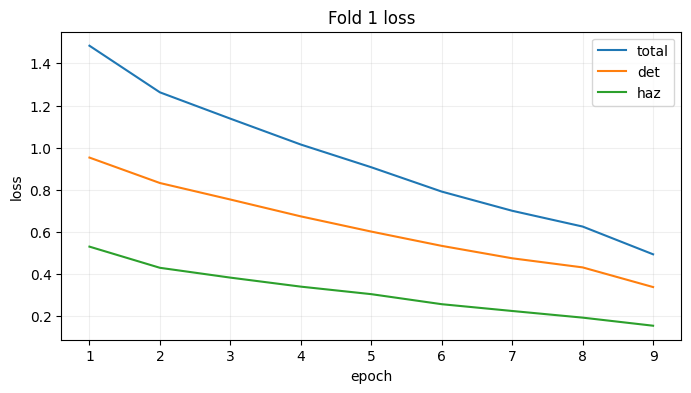

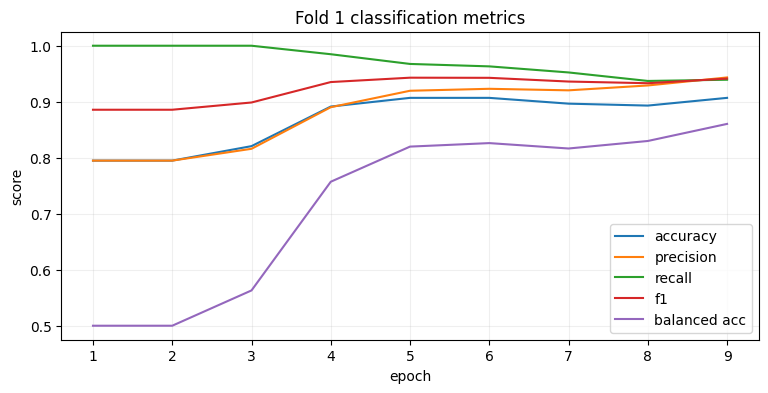

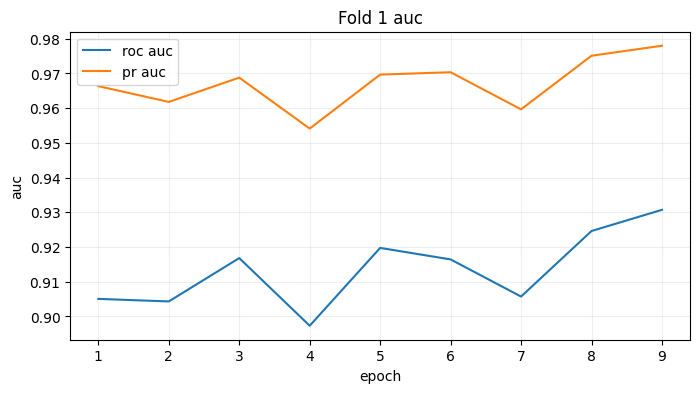

Best epoch fold 1: 5
Best confusion matrix:\n [[ 80  39]
 [ 15 446]]


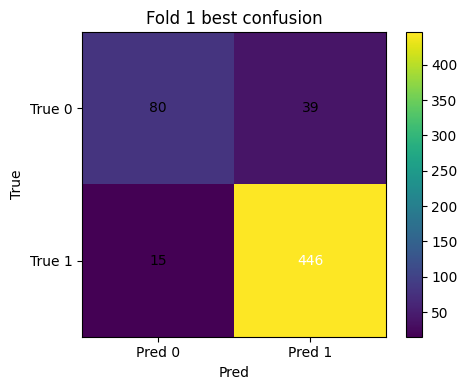


===== Fold 2/5 =====


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 01 | 65.6 min | loss=1.5430 (det=0.9552, haz=0.5878) | acc=0.794 prec=0.794 rec=1.000 f1=0.885 bal=0.500 roc=0.916 pr=0.975


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 02 | 64.8 min | loss=1.2988 (det=0.8359, haz=0.4629) | acc=0.794 prec=0.794 rec=1.000 f1=0.885 bal=0.500 roc=0.923 pr=0.973


...

Epoch 10 | 94.7 min | loss=0.4987 (det=0.2911, haz=0.2075) | acc=0.917 prec=0.926 rec=0.974 f1=0.949 bal=0.836 roc=0.958 pr=0.988


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 11 | 98.4 min | loss=0.4593 (det=0.2702, haz=0.1891) | acc=0.905 prec=0.916 rec=0.970 f1=0.942 bal=0.813 roc=0.953 pr=0.986


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 12 | 84.3 min | loss=0.3929 (det=0.2283, haz=0.1646) | acc=0.912 prec=0.934 rec=0.957 f1=0.945 bal=0.848 roc=0.955 pr=0.988
Early stopping at epoch 12 (patience=4).


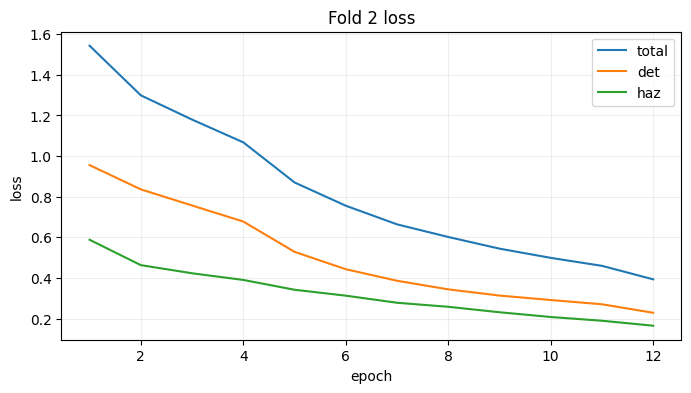

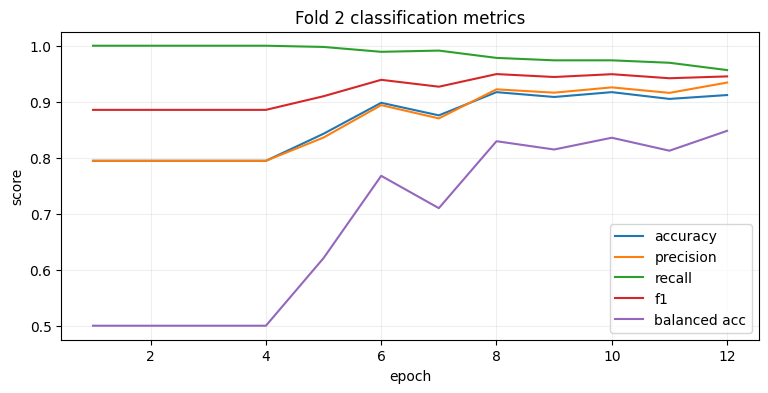

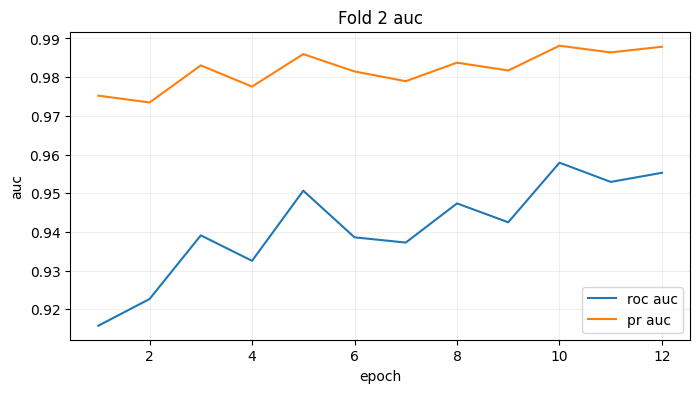

Best epoch fold 2: 8
Best confusion matrix:\n [[ 81  38]
 [ 10 450]]


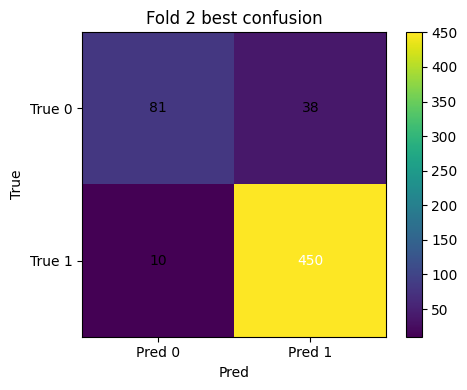


===== Fold 3/5 =====


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 01 | 78.3 min | loss=1.5087 (det=0.9558, haz=0.5528) | acc=0.794 prec=0.794 rec=1.000 f1=0.885 bal=0.500 roc=0.908 pr=0.973


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 02 | 84.1 min | loss=1.2752 (det=0.8320, haz=0.4431) | acc=0.794 prec=0.794 rec=1.000 f1=0.885 bal=0.500 roc=0.913 pr=0.969


...

Epoch 10 | 104.3 min | loss=0.5466 (det=0.3614, haz=0.1852) | acc=0.922 prec=0.930 rec=0.976 f1=0.952 bal=0.845 roc=0.952 pr=0.983


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 11 | 102.0 min | loss=0.5196 (det=0.3381, haz=0.1815) | acc=0.903 prec=0.945 rec=0.933 f1=0.939 bal=0.861 roc=0.944 pr=0.980


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 12 | 121.2 min | loss=0.4910 (det=0.3172, haz=0.1738) | acc=0.907 prec=0.926 rec=0.959 f1=0.942 bal=0.832 roc=0.952 pr=0.985


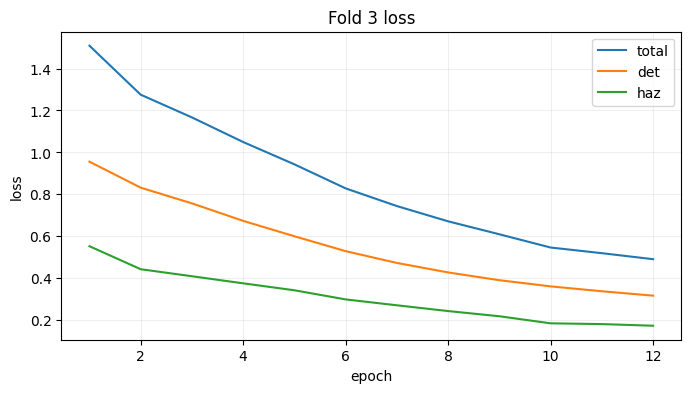

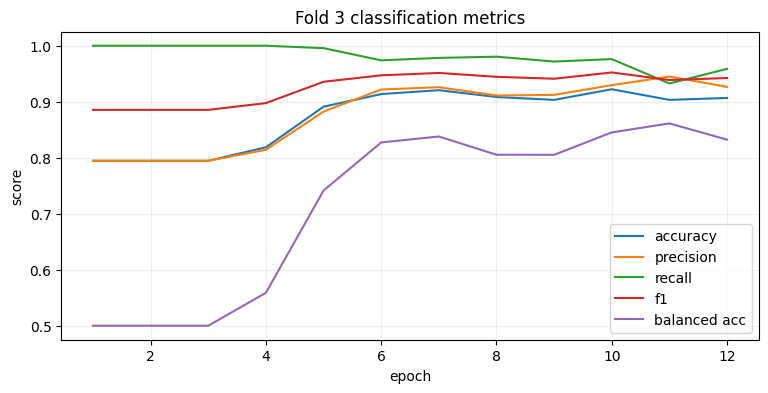

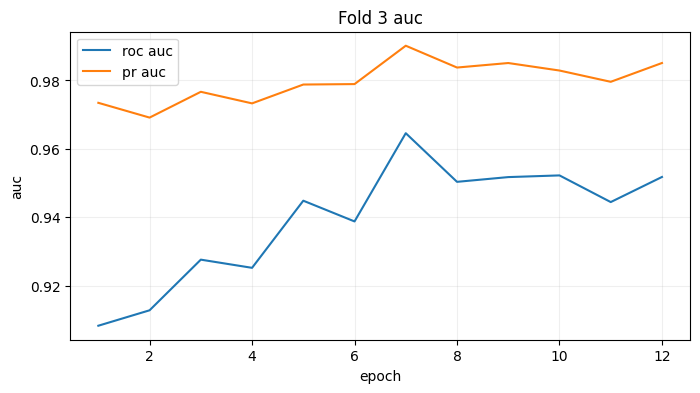

Best epoch fold 3: 10
Best confusion matrix:\n [[ 85  34]
 [ 11 449]]


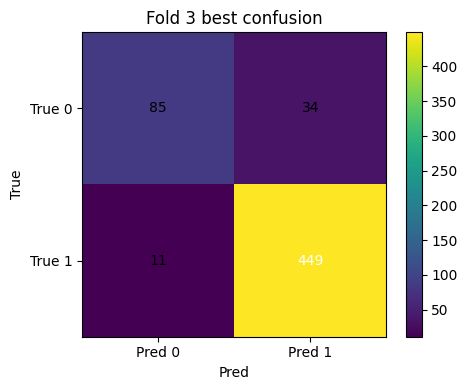


===== Fold 4/5 =====


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 01 | 85.2 min | loss=1.4902 (det=0.9609, haz=0.5293) | acc=0.796 prec=0.796 rec=1.000 f1=0.887 bal=0.500 roc=0.906 pr=0.969


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 02 | 127.1 min | loss=1.3061 (det=0.8384, haz=0.4677) | acc=0.796 prec=0.796 rec=1.000 f1=0.887 bal=0.500 roc=0.911 pr=0.962


...

Epoch 10 | 65.7 min | loss=0.5203 (det=0.2922, haz=0.2280) | acc=0.914 prec=0.925 rec=0.970 f1=0.947 bal=0.832 roc=0.942 pr=0.981


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 11 | 65.9 min | loss=0.4803 (det=0.2724, haz=0.2079) | acc=0.905 prec=0.923 rec=0.961 f1=0.942 bal=0.824 roc=0.935 pr=0.979


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 12 | 65.5 min | loss=0.4504 (det=0.2553, haz=0.1951) | acc=0.910 prec=0.938 rec=0.950 f1=0.944 bal=0.852 roc=0.937 pr=0.980


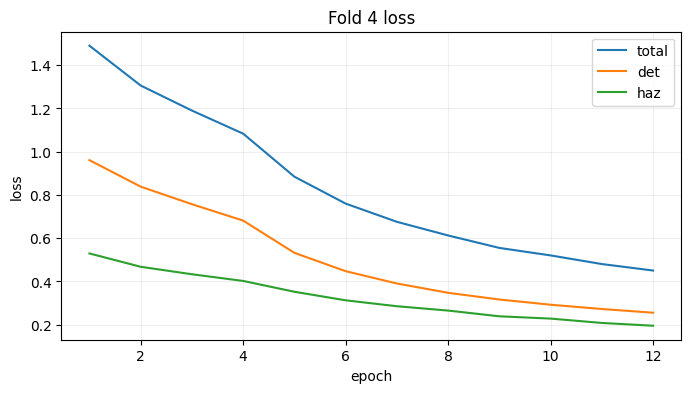

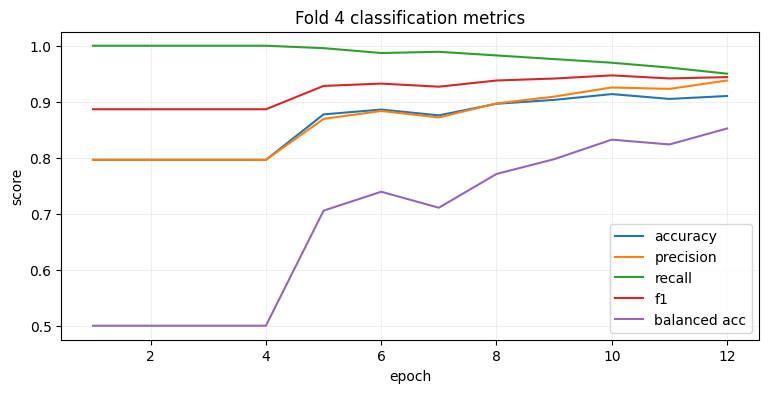

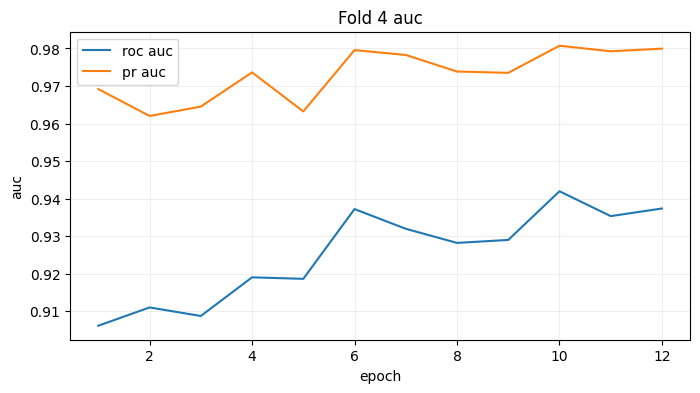

Best epoch fold 4: 10
Best confusion matrix:\n [[ 82  36]
 [ 14 447]]


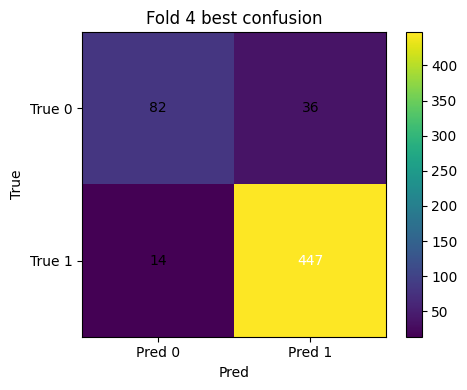


===== Fold 5/5 =====


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 01 | 65.5 min | loss=1.4819 (det=0.9575, haz=0.5243) | acc=0.796 prec=0.796 rec=1.000 f1=0.887 bal=0.500 roc=0.908 pr=0.972


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 02 | 65.4 min | loss=1.2823 (det=0.8390, haz=0.4433) | acc=0.796 prec=0.796 rec=1.000 f1=0.887 bal=0.500 roc=0.894 pr=0.966


...

Epoch 10 | 89.2 min | loss=0.5374 (det=0.3694, haz=0.1681) | acc=0.872 prec=0.877 rec=0.976 f1=0.924 bal=0.721 roc=0.913 pr=0.972


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 11 | 84.2 min | loss=0.4925 (det=0.3400, haz=0.1525) | acc=0.891 prec=0.898 rec=0.974 f1=0.934 bal=0.771 roc=0.910 pr=0.972


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 12 | 94.0 min | loss=0.4600 (det=0.3215, haz=0.1384) | acc=0.884 prec=0.899 rec=0.963 f1=0.930 bal=0.770 roc=0.907 pr=0.971


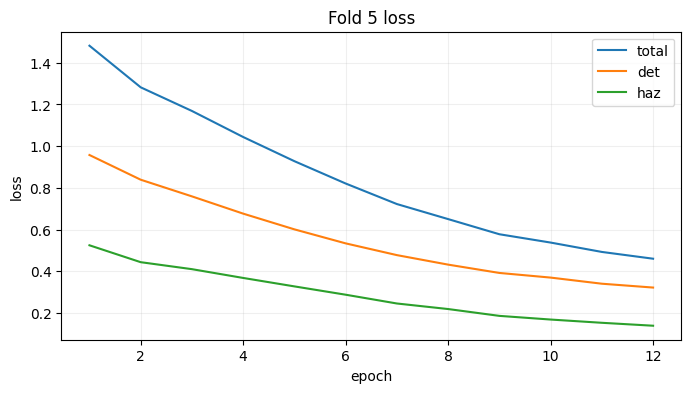

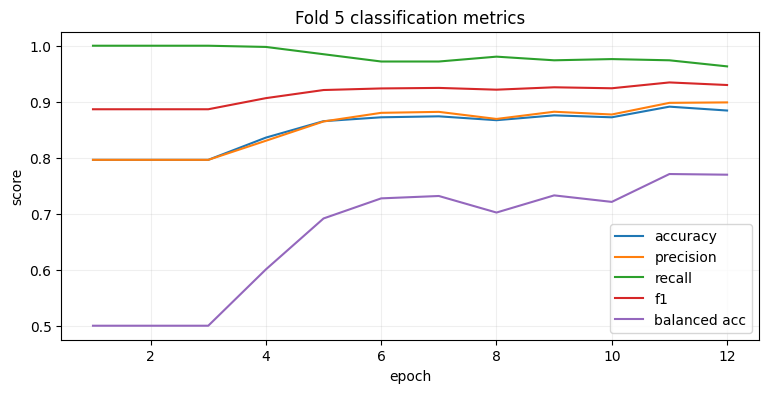

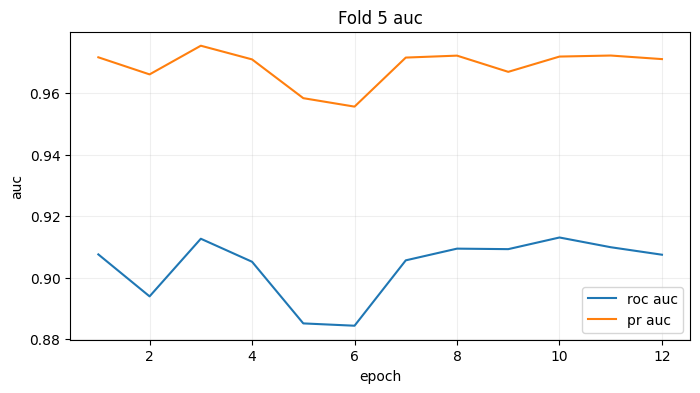

Best epoch fold 5: 11
Best confusion matrix:\n [[ 67  51]
 [ 12 449]]


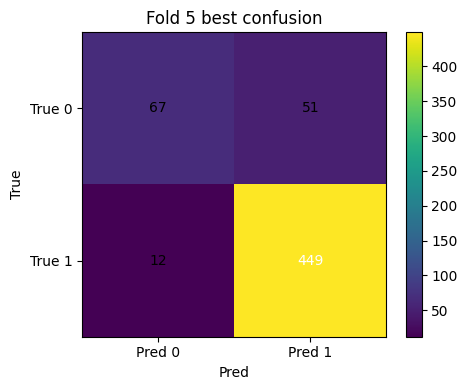

In [6]:
def run_stratified_kfold(
    dataset,
    hazard_labels,
    n_splits=5,
    epochs=12,
    batch_size=2,
    lr=1e-4,
    weight_decay=1e-4,
    lambda_haz=1.0,
    threshold=0.5,
    early_stop_patience=4,
    num_workers=0,
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_summaries = []
    histories = []
    fold_best_epochs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(np.arange(len(dataset)), hazard_labels), start=1):
        print(f"\n===== Fold {fold}/{n_splits} =====")

        train_loader = DataLoader(
            Subset(dataset, train_idx),
            batch_size=batch_size,
            shuffle=True,
            collate_fn=collate_fn,
            num_workers=num_workers,
            pin_memory=(DEVICE.type == "cuda"),
        )
        val_loader = DataLoader(
            Subset(dataset, val_idx),
            batch_size=batch_size,
            shuffle=False,
            collate_fn=collate_fn,
            num_workers=num_workers,
            pin_memory=(DEVICE.type == "cuda"),
        )

        model = DetectorWithHazardHead(num_classes=3).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

        history = {
            "loss_total": [], "loss_det": [], "loss_haz": [],
            "acc": [], "prec": [], "rec": [], "f1": [], "bal_acc": [],
            "roc_auc": [], "pr_auc": []
        }

        best_f1 = -1.0
        best_metrics = None
        best_epoch = 0
        best_state = None
        no_improve = 0

        for ep in range(1, epochs + 1):
            t0 = time.time()
            loss_total, loss_det, loss_haz = train_one_epoch(model, train_loader, optimizer, lambda_haz=lambda_haz)
            metrics, _, _ = eval_hazard(model, val_loader, threshold=threshold)
            scheduler.step(metrics["f1"])

            history["loss_total"].append(loss_total)
            history["loss_det"].append(loss_det)
            history["loss_haz"].append(loss_haz)
            history["acc"].append(metrics["acc"])
            history["prec"].append(metrics["prec"])
            history["rec"].append(metrics["rec"])
            history["f1"].append(metrics["f1"])
            history["bal_acc"].append(metrics["bal_acc"])
            history["roc_auc"].append(metrics["roc_auc"])
            history["pr_auc"].append(metrics["pr_auc"])

            dt = time.time() - t0
            print(
                f"Epoch {ep:02d} | {dt/60:.1f} min | "
                f"loss={loss_total:.4f} (det={loss_det:.4f}, haz={loss_haz:.4f}) | "
                f"acc={metrics['acc']:.3f} prec={metrics['prec']:.3f} rec={metrics['rec']:.3f} "
                f"f1={metrics['f1']:.3f} bal={metrics['bal_acc']:.3f} roc={metrics['roc_auc']:.3f} pr={metrics['pr_auc']:.3f}"
            )

            if metrics["f1"] > best_f1:
                best_f1 = metrics["f1"]
                best_metrics = metrics
                best_epoch = ep
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1

            if no_improve >= early_stop_patience:
                print(f"Early stopping at epoch {ep} (patience={early_stop_patience}).")
                break

        if best_state is not None:
            model.load_state_dict(best_state)

        histories.append(history)
        fold_summaries.append(best_metrics)
        fold_best_epochs.append(best_epoch)

        plot_history(history, title_prefix=f"Fold {fold}")
        print(f"Best epoch fold {fold}: {best_epoch}")
        print("Best confusion matrix:\\n", best_metrics["cm"])
        plot_confusion(best_metrics["cm"], title=f"Fold {fold} best confusion")

    return fold_summaries, histories, fold_best_epochs


# Tuning config
CV_CONFIG = {
    "n_splits": 5,
    "epochs": 12,
    "batch_size": 2,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "lambda_haz": 1.0,
    "threshold": 0.5,
    "early_stop_patience": 4,
    "num_workers": 0,
}

fold_summaries, histories, fold_best_epochs = run_stratified_kfold(
    dataset=trainval_dataset,
    hazard_labels=trainval_labels,
    **CV_CONFIG,
)





===== Cross-validation summary (mean ± std) =====
acc     : 0.9102 ± 0.0107
prec    : 0.9190 ± 0.0110
rec     : 0.9731 ± 0.0040
f1      : 0.9452 ± 0.0062
bal_acc : 0.8195 ± 0.0256
spec    : 0.6660 ± 0.0511
mcc     : 0.7071 ± 0.0394
roc_auc : 0.9342 ± 0.0165
pr_auc  : 0.9779 ± 0.0058
brier   : 0.0789 ± 0.0097


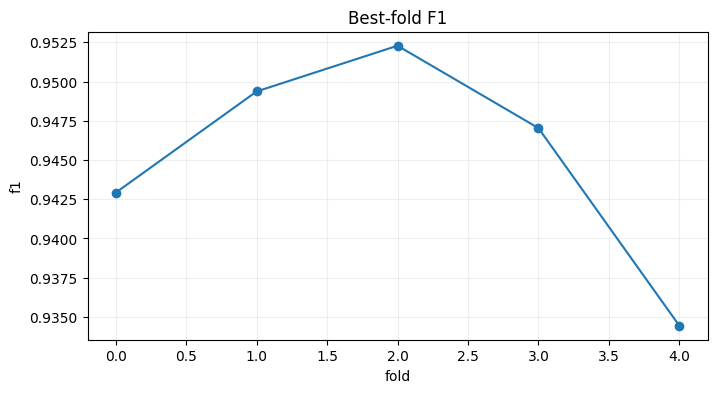

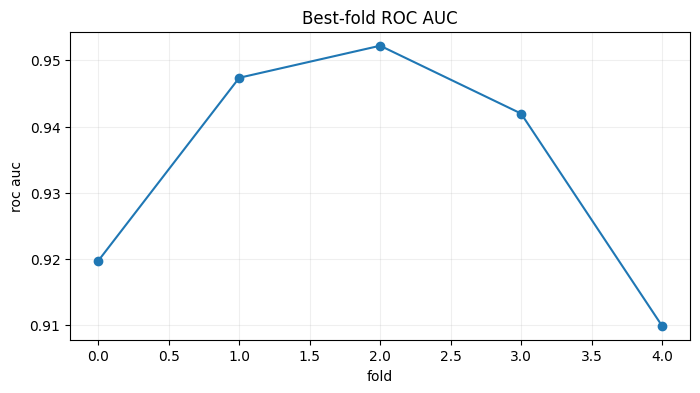

Suggested final epochs from CV median best epoch: 10

===== Final training on train+valid =====


/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
/var/folders/5g/3f91rn5j7d56mxn3p093gzdc0000gp/T/ipykernel_71334/2508515210.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 01/10 | 123.1 min | total=1.4764 det=0.9441 haz=0.5323
Epoch 02/10 | 92.9 min | total=1.2485 det=0.8184 haz=0.4301
Epoch 03/10 | 77.7 min | total=1.1328 det=0.7388 haz=0.3940
Epoch 04/10 | 78.8 min | total=1.0054 det=0.6602 haz=0.3453
Epoch 05/10 | 78.4 min | total=0.8827 det=0.5841 haz=0.2986
Epoch 06/10 | 114.2 min | total=0.7743 det=0.5179 haz=0.2564
Epoch 07/10 | 99.8 min | total=0.6950 det=0.4643 haz=0.2307
Epoch 08/10 | 145.4 min | total=0.6229 det=0.4219 haz=0.2010
Epoch 09/10 | 172.1 min | total=0.5639 det=0.3868 haz=0.1771
Epoch 10/10 | 161.7 min | total=0.5143 det=0.3593 haz=0.1550

===== Final TEST evaluation =====
acc     : 0.9002
prec    : 0.9216
rec     : 0.9592
f1      : 0.9400
bal_acc : 0.7995
spec    : 0.6398
mcc     : 0.6484
roc_auc : 0.9287
pr_auc  : 0.9790
brier   : 0.0804
Confusion matrix:\n [[103  58]
 [ 29 682]]


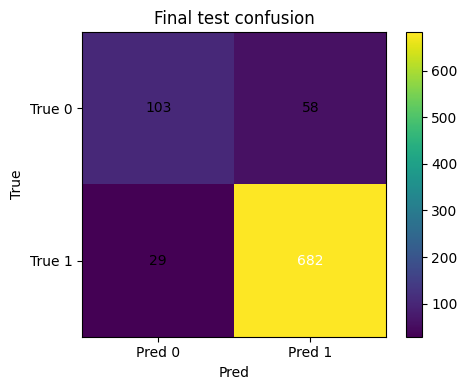

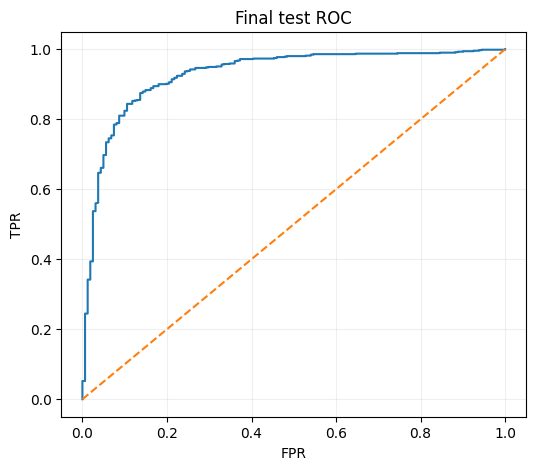

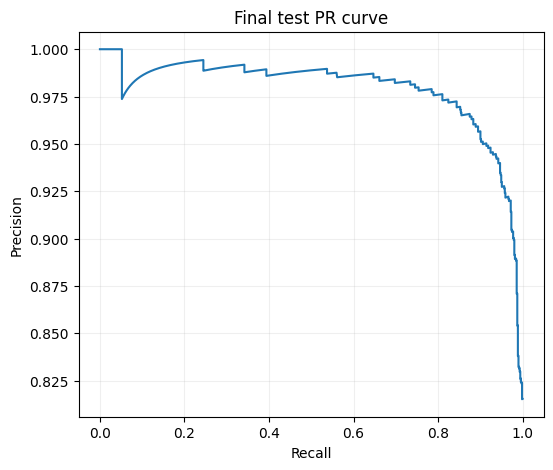


===== Threshold optimization on final test =====
Best threshold by F1: 0.310


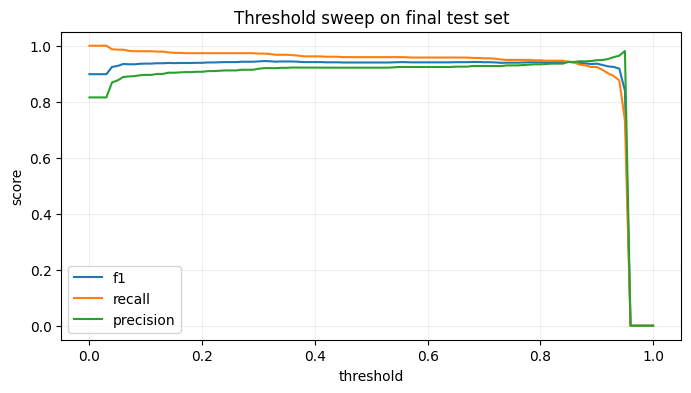


===== Final TEST metrics at tuned threshold =====
acc     : 0.9083
prec    : 0.9201
rec     : 0.9719
f1      : 0.9453
bal_acc : 0.7996
spec    : 0.6273
mcc     : 0.6725
roc_auc : 0.9287
pr_auc  : 0.9790
brier   : 0.0804
Confusion matrix (tuned):
 [[101  60]
 [ 20 691]]


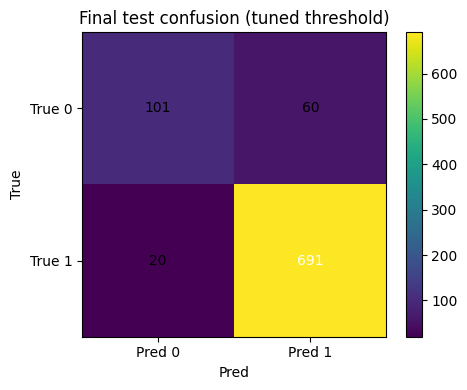


===== Bootstrap 95% CIs on final test metrics =====
acc     : mean=0.9085 95%CI=(0.8876, 0.9266)
prec    : mean=0.9202 95%CI=(0.9004, 0.9392)
rec     : mean=0.9720 95%CI=(0.9585, 0.9834)
f1      : mean=0.9453 95%CI=(0.9328, 0.9564)
bal_acc : mean=0.8006 95%CI=(0.7638, 0.8354)
spec    : mean=0.6292 95%CI=(0.5532, 0.7006)
mcc     : mean=0.6741 95%CI=(0.6043, 0.7339)
roc_auc : mean=0.9292 95%CI=(0.9046, 0.9502)
pr_auc  : mean=0.9791 95%CI=(0.9677, 0.9881)
brier   : mean=0.0802 95%CI=(0.0654, 0.0966)
Saved summary CSV: /Users/lucass/Downloads/ASDRP Drone/model_results_summary.csv


In [7]:
# Aggregate CV metrics
metrics_keys = ["acc", "prec", "rec", "f1", "bal_acc", "spec", "mcc", "roc_auc", "pr_auc", "brier"]
agg = {k: [] for k in metrics_keys}

for m in fold_summaries:
    for k in metrics_keys:
        agg[k].append(m[k])

print("\n===== Cross-validation summary (mean ± std) =====")
for k in metrics_keys:
    vals = np.array(agg[k], dtype=float)
    print(f"{k:8s}: {np.nanmean(vals):.4f} ± {np.nanstd(vals):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(agg["f1"], marker="o")
plt.xlabel("fold")
plt.ylabel("f1")
plt.title("Best-fold F1")
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(agg["roc_auc"], marker="o")
plt.xlabel("fold")
plt.ylabel("roc auc")
plt.title("Best-fold ROC AUC")
plt.grid(alpha=0.2)
plt.show()


# Final holdout test evaluation (train+valid -> train, test -> untouched evaluation)
def train_full_and_eval_test(
    train_dataset,
    test_dataset,
    epochs,
    batch_size,
    lr,
    weight_decay,
    lambda_haz,
    threshold,
    num_workers=0,
):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )

    model = DetectorWithHazardHead(num_classes=3).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n===== Final training on train+valid =====")
    for ep in range(1, epochs + 1):
        t0 = time.time()
        loss_total, loss_det, loss_haz = train_one_epoch(model, train_loader, optimizer, lambda_haz=lambda_haz)
        dt = time.time() - t0
        print(f"Epoch {ep:02d}/{epochs} | {dt/60:.1f} min | total={loss_total:.4f} det={loss_det:.4f} haz={loss_haz:.4f}")

    print("\n===== Final TEST evaluation =====")
    test_metrics, y_true, y_prob = eval_hazard(model, test_loader, threshold=threshold)
    for k in ["acc", "prec", "rec", "f1", "bal_acc", "spec", "mcc", "roc_auc", "pr_auc", "brier"]:
        print(f"{k:8s}: {test_metrics[k]:.4f}")

    print("Confusion matrix:\\n", test_metrics["cm"])
    plot_confusion(test_metrics["cm"], title="Final test confusion")
    plot_roc_pr(y_true, y_prob, title_prefix="Final test")

    return model, test_metrics, y_true, y_prob


best_epoch_estimate = int(np.clip(np.round(np.nanmedian(np.array(fold_best_epochs, dtype=float))), 3, CV_CONFIG["epochs"]))
print("Suggested final epochs from CV median best epoch:", best_epoch_estimate)

RUN_FINAL_TEST = True
if RUN_FINAL_TEST:
    final_model, final_test_metrics, test_y_true, test_y_prob = train_full_and_eval_test(
        train_dataset=trainval_dataset,
        test_dataset=test_dataset,
        epochs=best_epoch_estimate,
        batch_size=CV_CONFIG["batch_size"],
        lr=CV_CONFIG["lr"],
        weight_decay=CV_CONFIG["weight_decay"],
        lambda_haz=CV_CONFIG["lambda_haz"],
        threshold=CV_CONFIG["threshold"],
        num_workers=CV_CONFIG["num_workers"],
    )





def find_best_threshold(y_true, y_prob, metric="f1", n_steps=101):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    thresholds = np.linspace(0.0, 1.0, n_steps)

    best_t = 0.5
    best_val = -np.inf
    rows = []

    for t in thresholds:
        m = compute_metrics(y_true, y_prob, threshold=float(t))
        val = m.get(metric, np.nan)
        rows.append({
            "threshold": float(t),
            "acc": m["acc"],
            "prec": m["prec"],
            "rec": m["rec"],
            "f1": m["f1"],
            "bal_acc": m["bal_acc"],
            "spec": m["spec"],
            "roc_auc": m["roc_auc"],
            "pr_auc": m["pr_auc"],
            "mcc": m["mcc"],
            "brier": m["brier"],
        })
        if np.isfinite(val) and val > best_val:
            best_val = val
            best_t = float(t)

    return best_t, rows


def plot_threshold_sweep(rows):
    th = np.array([r["threshold"] for r in rows], dtype=float)
    f1 = np.array([r["f1"] for r in rows], dtype=float)
    rec = np.array([r["rec"] for r in rows], dtype=float)
    prec = np.array([r["prec"] for r in rows], dtype=float)

    plt.figure(figsize=(8, 4))
    plt.plot(th, f1, label="f1")
    plt.plot(th, rec, label="recall")
    plt.plot(th, prec, label="precision")
    plt.xlabel("threshold")
    plt.ylabel("score")
    plt.title("Threshold sweep on final test set")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


def bootstrap_metric_cis(y_true, y_prob, threshold=0.5, n_boot=1000, seed=42):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    rng = np.random.default_rng(seed)
    n = len(y_true)

    keys = ["acc", "prec", "rec", "f1", "bal_acc", "spec", "mcc", "roc_auc", "pr_auc", "brier"]
    vals = {k: [] for k in keys}

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        yp = y_prob[idx]
        m = compute_metrics(yt, yp, threshold=threshold)
        for k in keys:
            v = m.get(k, np.nan)
            if np.isfinite(v):
                vals[k].append(float(v))

    ci = {}
    for k in keys:
        arr = np.array(vals[k], dtype=float)
        if arr.size == 0:
            ci[k] = {"mean": np.nan, "lo95": np.nan, "hi95": np.nan}
        else:
            ci[k] = {
                "mean": float(np.nanmean(arr)),
                "lo95": float(np.nanpercentile(arr, 2.5)),
                "hi95": float(np.nanpercentile(arr, 97.5)),
            }
    return ci


def save_results_csv(out_csv_path, cv_agg_dict, test_metrics, test_ci, best_threshold):
    import csv

    rows = []
    for k, vals in cv_agg_dict.items():
        a = np.array(vals, dtype=float)
        rows.append({
            "section": "cv",
            "metric": k,
            "value": float(np.nanmean(a)),
            "std": float(np.nanstd(a)),
            "ci_low": "",
            "ci_high": "",
            "threshold": "",
        })

    for k, v in test_metrics.items():
        if k == "cm":
            continue
        if isinstance(v, (int, float, np.floating)):
            ci_k = test_ci.get(k, {"lo95": np.nan, "hi95": np.nan})
            rows.append({
                "section": "test",
                "metric": k,
                "value": float(v),
                "std": "",
                "ci_low": ci_k.get("lo95", np.nan),
                "ci_high": ci_k.get("hi95", np.nan),
                "threshold": float(best_threshold),
            })

    with open(out_csv_path, "w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=["section", "metric", "value", "std", "ci_low", "ci_high", "threshold"],
        )
        writer.writeheader()
        writer.writerows(rows)


if RUN_FINAL_TEST:
    print("\n===== Threshold optimization on final test =====")
    best_t, thr_rows = find_best_threshold(test_y_true, test_y_prob, metric="f1", n_steps=101)
    print(f"Best threshold by F1: {best_t:.3f}")
    plot_threshold_sweep(thr_rows)

    tuned_test_metrics = compute_metrics(test_y_true, test_y_prob, threshold=best_t)
    print("\n===== Final TEST metrics at tuned threshold =====")
    for k in ["acc", "prec", "rec", "f1", "bal_acc", "spec", "mcc", "roc_auc", "pr_auc", "brier"]:
        print(f"{k:8s}: {tuned_test_metrics[k]:.4f}")
    print("Confusion matrix (tuned):\n", tuned_test_metrics["cm"])
    plot_confusion(tuned_test_metrics["cm"], title="Final test confusion (tuned threshold)")

    print("\n===== Bootstrap 95% CIs on final test metrics =====")
    test_ci = bootstrap_metric_cis(test_y_true, test_y_prob, threshold=best_t, n_boot=1000, seed=42)
    for k in ["acc", "prec", "rec", "f1", "bal_acc", "spec", "mcc", "roc_auc", "pr_auc", "brier"]:
        c = test_ci[k]
        print(f"{k:8s}: mean={c['mean']:.4f} 95%CI=({c['lo95']:.4f}, {c['hi95']:.4f})")

    out_csv = "/Users/lucass/Downloads/ASDRP Drone/model_results_summary.csv"
    save_results_csv(out_csv, agg, tuned_test_metrics, test_ci, best_t)
    print("Saved summary CSV:", out_csv)



# Persist trained model weights for future inference (no retraining needed)
if RUN_FINAL_TEST:
    model_out = "/Users/lucass/Downloads/ASDRP Drone/final_model.pt"
    torch.save(final_model.state_dict(), model_out)
    print("Saved model weights:", model_out)


def load_saved_model(weights_path="/Users/lucass/Downloads/ASDRP Drone/final_model.pt"):
    m = DetectorWithHazardHead(num_classes=3).to(DEVICE)
    m.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    m.eval()
    return m



In [5]:
# RealWorld batch inference (5 images) - robust version
import os
import torch
from PIL import Image
import torchvision.transforms as T

REALWORLD_DIR = "/Users/lucass/Downloads/ASDRP Drone/RealWorld"
MODEL_PATH = "/Users/lucass/Downloads/ASDRP Drone/final_model.pt"
THRESHOLD = 0.31

# Ensure model class/device exist
if 'DetectorWithHazardHead' not in globals():
    raise NameError("DetectorWithHazardHead is not defined. Run the model-definition cells first.")
if 'DEVICE' not in globals():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Prefer in-memory model if present; otherwise load saved weights
if 'final_model' in globals():
    infer_model = final_model
else:
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"Saved weights not found at {MODEL_PATH}. "
            "Run the final training cell once (with RUN_FINAL_TEST=True) to create final_model.pt."
        )
    infer_model = DetectorWithHazardHead(num_classes=3).to(DEVICE)
    infer_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

infer_model.eval()

if not os.path.isdir(REALWORLD_DIR):
    raise FileNotFoundError(f"RealWorld folder not found: {REALWORLD_DIR}")

img_paths = sorted([
    os.path.join(REALWORLD_DIR, fn)
    for fn in os.listdir(REALWORLD_DIR)
    if fn.lower().endswith((".jpg", ".jpeg", ".png"))
])

if len(img_paths) == 0:
    raise RuntimeError(f"No .jpg/.jpeg/.png images found in {REALWORLD_DIR}")

results = []
for pth in img_paths:
    img = Image.open(pth).convert("RGB")
    x = T.ToTensor()(img).to(DEVICE)
    with torch.no_grad():
        _, hazard_prob = infer_model([x])
    prob = float(hazard_prob[0].item())
    label = "Hazardous" if prob >= THRESHOLD else "Nonhazardous"
    results.append((os.path.basename(pth), prob, label))

print(f"RealWorld predictions (threshold={THRESHOLD:.2f}):")
for name, prob, label in results:
    print(f"- {name}: {label} (p={prob:.4f})")



NameError: DetectorWithHazardHead is not defined. Run the model-definition cells first.